CONECTIVIDAD

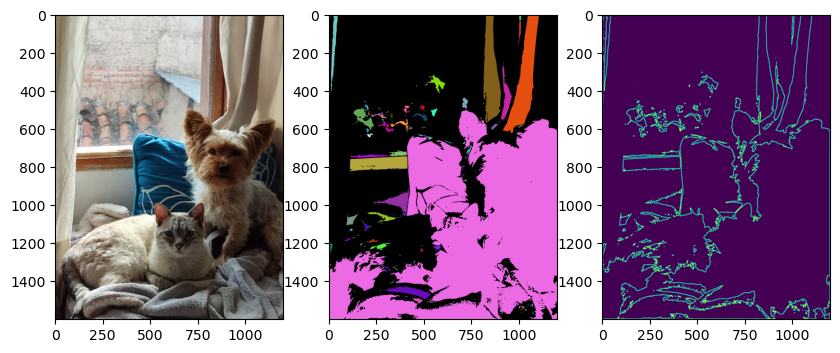

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen=cv2.imread('imagentango.jpg')

gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(7,7),0)
_, binarizada=cv2.threshold(blur,0,255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
#regiones
cant, region=cv2.connectedComponents(binarizada)

colores=np.random.randint(0,255, size=(cant,3),dtype=np.uint8)
colores[0] = [0,0,0]
color_regionb = colores[region]

#fronteras
contorno,_ = cv2.findContours(binarizada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lineas=cv2.drawContours(np.zeros_like(gray), contorno, -1, 255, 2)

plt.figure(figsize=(10,5))
plt.subplot(131)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.imshow(color_regionb)

plt.subplot(133)
plt.imshow(lineas)


plt.tight_layout
plt.show()

DISTANCIAS

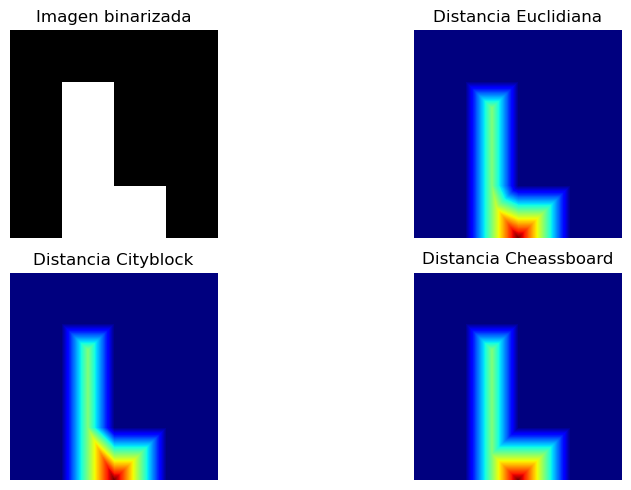

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img=np.zeros((200,200),dtype=np.uint8)
img[50:150,50:100]=1
img[150:200,50:150]=1

def distancia (img_binarizada):
    invertir=1-img_binarizada
    
    #euclideana
    dist_euclidiana=cv2.distanceTransform(img_binarizada,cv2.DIST_L2,3)
    #CITYBLOCK
    dist_cityblock=cv2.distanceTransform(img_binarizada,cv2.DIST_L1,3)
    #CHEASSBOARD
    dist_cheassboard=cv2.distanceTransform(img_binarizada,cv2.DIST_C,3)
    
    return dist_euclidiana,dist_cityblock,dist_cheassboard

euclidiana,cityblock,cheassboard=distancia(img)

def normalizar(dist):
    return cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

normeuclidiana=normalizar(euclidiana)
normcityblock=normalizar(cityblock)
normcheassboard=normalizar(cheassboard)

plt.figure(figsize=(10,5))
plt.subplot(221)
plt.imshow(img, cmap='gray')
plt.title('Imagen binarizada')
plt.axis('off')

plt.subplot(222)
plt.imshow(normeuclidiana, cmap='jet')
plt.title('Distancia Euclidiana')
plt.axis('off')

plt.subplot(223)
plt.imshow(normcityblock, cmap='jet')
plt.title('Distancia Cityblock')        
plt.axis('off')

plt.subplot(224)
plt.imshow(normcheassboard, cmap='jet')
plt.title('Distancia Cheassboard')
plt.axis('off')

plt.tight_layout()
plt.show()

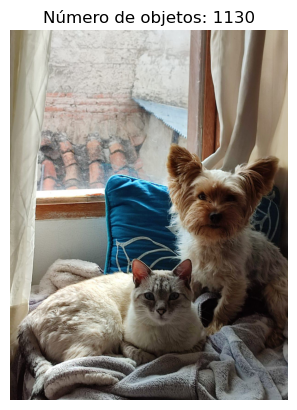

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.color import label2rgb


def contar(imagen):
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    _, binarizada=cv2.threshold(gray,127,255, cv2.THRESH_BINARY)
    etiquetar=measure.label(binarizada, connectivity=2) #conectividad con 4=2 , 8=1	
    num= np.max(etiquetar) #cuenta el número de etiquetas
    return num

imagen = cv2.imread('imagentango.jpg')
contarr = contar(imagen)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f'Número de objetos: {contarr}')  
plt.axis('off')
plt.show()
    



COMBINACION 2 PREVIOS

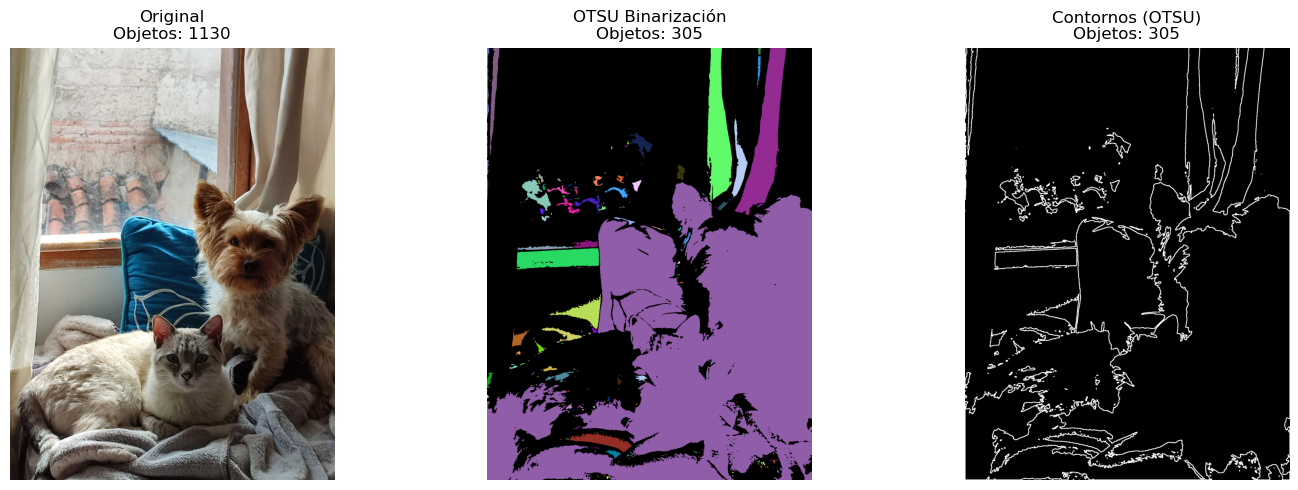

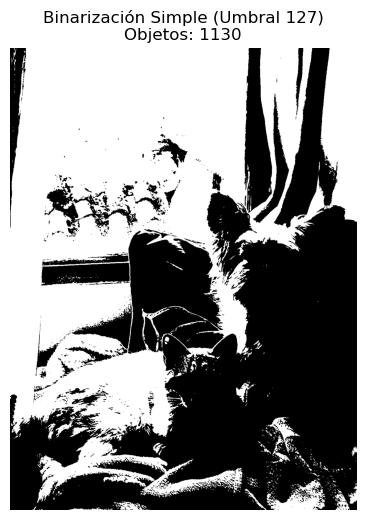

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.color import label2rgb

def contar_objetos(imagen_gris):
    """Cuenta el número de objetos en una imagen binaria."""
    etiquetar = measure.label(imagen_gris, connectivity=2)
    num_objetos = np.max(etiquetar)
    return num_objetos

# Cargar la imagen original
imagen_original = cv2.imread('imagentango.jpg')
gray_original = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)
num_original = contar_objetos(gray_original > 127) # Binarización simple para contar en original

# --- Proceso 1 (Binarización con OTSU y Componentes Conectados) ---
gray_otsu = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)
blur_otsu = cv2.GaussianBlur(gray_otsu, (7, 7), 0)
_, binarizada_otsu = cv2.threshold(blur_otsu, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
cant_otsu, region_otsu = cv2.connectedComponents(binarizada_otsu)
num_objetos_otsu = cant_otsu - 1 # Restamos el fondo

colores_otsu = np.random.randint(0, 255, size=(cant_otsu, 3), dtype=np.uint8)
colores_otsu[0] = [0, 0, 0]
color_regionb_otsu = colores_otsu[region_otsu]
contorno_otsu, _ = cv2.findContours(binarizada_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lineas_otsu = cv2.drawContours(np.zeros_like(gray_otsu), contorno_otsu, -1, 255, 2)

# --- Proceso 2 (Función 'contar' con umbral fijo) ---
gray_contar = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)
_, binarizada_contar = cv2.threshold(gray_contar, 127, 255, cv2.THRESH_BINARY)
num_objetos_contar = contar_objetos(binarizada_contar)

# --- Mostrar los resultados en subplots ---
plt.figure(figsize=(15, 5))

# Imagen Original
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB))
plt.title(f'Original\nObjetos: {num_original}')
plt.axis('off')

# Proceso 1 (OTSU y Componentes Conectados)
plt.subplot(1, 3, 2)
plt.imshow(color_regionb_otsu)
plt.title(f'OTSU Binarización\nObjetos: {num_objetos_otsu}')
plt.axis('off')

# Proceso 2 (Función 'contar')
plt.subplot(1, 3, 3)
plt.imshow(lineas_otsu, cmap='gray')
plt.title(f'Contornos (OTSU)\nObjetos: {num_objetos_otsu}')
plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar la imagen usada por la función 'contar' aparte
plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.imshow(binarizada_contar, cmap='gray')
plt.title(f'Binarización Simple (Umbral 127)\nObjetos: {num_objetos_contar}')
plt.axis('off')
plt.show()

etiquetado

(-0.5, 1199.5, 1599.5, -0.5)

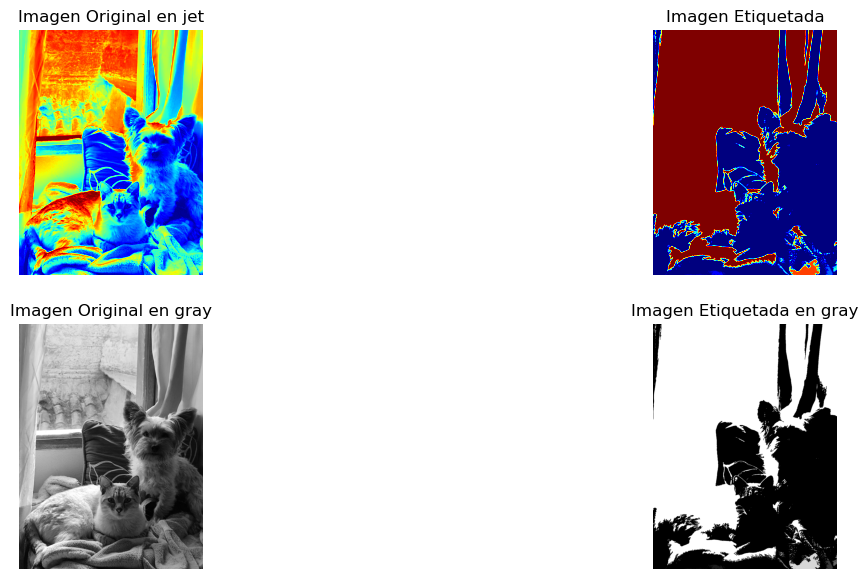

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
from skimage import measure

def etiquetar(img):
    #umbralizacion binaria
    _, imgBinaria = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    #encontrar contornos
    contorno, _ = cv2.findContours(imgBinaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_etiquetada = np.zeros_like(img, dtype=np.uint8)
    for i, contornoss in enumerate(contorno):
        cv2.drawContours(img_etiquetada, [contornoss], -1, (i+1), -1) 
    return img_etiquetada
    
imgen=cv2.imread('imagentango.jpg',0)

etiquetada=etiquetar(imgen)


plt.figure(figsize=(15,7))  

plt.subplot(221)
plt.imshow(imgen, cmap='jet')      
plt.title('Imagen Original en jet')
plt.axis('off')

plt.subplot(222)
plt.imshow(etiquetada, cmap='jet')
plt.title('Imagen Etiquetada')
plt.axis('off')

plt.subplot(223)
plt.imshow(imgen, cmap='gray')
plt.title('Imagen Original en gray')
plt.axis('off')

plt.subplot(224)
plt.imshow(etiquetada, cmap='gray')
plt.title('Imagen Etiquetada en gray')
plt.axis('off')





etiquetado nativo de skimage

(-0.5, 1199.5, 1599.5, -0.5)

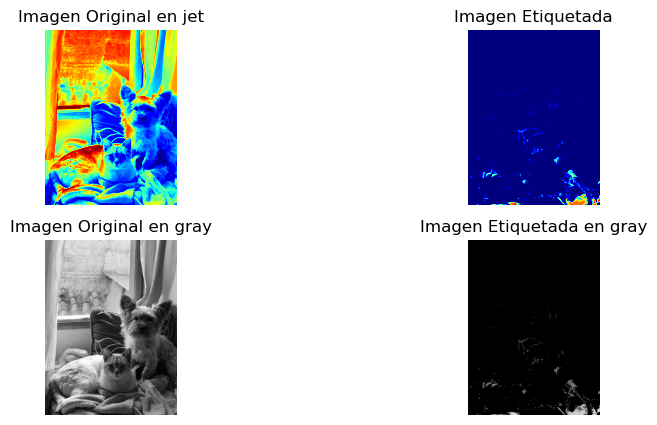

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img_gray=cv2.imread('imagentango.jpg', 0)

_, img_binarizada = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
img_etiquetada = measure.label(img_binarizada, connectivity=1) # Conectividad 4

plt.figure(figsize=(10, 5))
plt.subplot(221)
plt.imshow(img_gray, cmap='jet')
plt.title('Imagen Original en jet')
plt.axis('off')

plt.subplot(222)
plt.imshow(img_etiquetada, cmap='jet')
plt.title('Imagen Etiquetada')
plt.axis('off')

plt.subplot(223)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen Original en gray')    
plt.axis('off')

plt.subplot(224)
plt.imshow(img_etiquetada, cmap='gray')
plt.title('Imagen Etiquetada en gray')
plt.axis('off') 



conteo con cv2

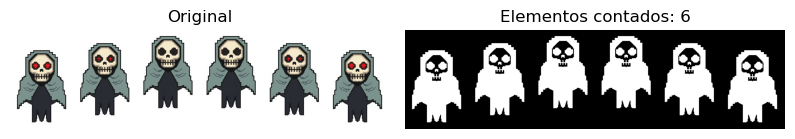

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def conteo2(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, imgbin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contornos, _ = cv2.findContours(imgbin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    count = len(contornos)
    return count, imgbin

imagen = cv2.imread(r"SpriteGhostj.jpg")

total, binarizada = conteo2(imagen)


plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')



plt.subplot(1, 3, 2)
plt.title(f"Elementos contados: {total}")
plt.imshow(cv2.cvtColor(binarizada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

conteo con label

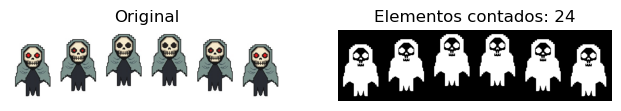

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar2 (img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_binarizada = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contorno= measure.label(img_binarizada, connectivity=2) #conectividad con 4=2 , 8=1
    cont=np.max(contorno) #cuenta el número de etiquetas
    
    return cont, img_binarizada

imagen = cv2.imread(r"SpriteGhostj.jpg")
contado, bin=contar2(imagen)

plt.figure(figsize=(12, 5))
plt.subplot(231)
plt.title("Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(232)
plt.title(f"Elementos contados: {contado}")
plt.imshow(bin, cmap='gray')
plt.axis('off')

plt.show()